## Imports e configurações

In [1]:
import pandas as pd
import psycopg2
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


load_dotenv("../.env")

DB_CONFIG = {
    'host': os.getenv('POSTGRES_HOST'),
    'port': int(os.getenv('POSTGRES_PORT')),
    'database': os.getenv('POSTGRES_DB'),
    'user': os.getenv('POSTGRES_USER'),
    'password': os.getenv('POSTGRES_PASSWORD')
}


## Carregamento dos dados

In [2]:
QUERY = "SELECT * FROM silver.fifa21_players;"


plt.style.use('seaborn-v0_8')
sns.set_theme(context="notebook", style="whitegrid")

conn = psycopg2.connect(**DB_CONFIG)

df = pd.read_sql(QUERY, conn)

conn.close()

df.head()

/tmp/ipykernel_26380/2403009786.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(QUERY, conn)


,player_id,long_name,name,nationality,positions,age,overall_rating,potential_rating,team,contract_period,...,defense_work_rate,international_reputation,pace,shooting,passing,dribbling_stat,defending_stat,physical,hits,created_at
0,158023,Lionel Messi,L. Messi,Argentina,RW ST CF,33,93,93,FC Barcelona,2004 ~ 2021,...,Low,5,85,92,91,95,38,65,372,2026-01-19 01:25:39.382927
1,20801,C. Ronaldo dos Santos Aveiro,Cristiano Ronaldo,Portugal,ST LW,35,92,92,Juventus,2018 ~ 2022,...,Low,5,89,93,81,89,35,77,344,2026-01-19 01:25:39.382927
2,200389,Jan Oblak,J. Oblak,Slovenia,GK,27,91,93,Atlético Madrid,2014 ~ 2023,...,Medium,3,87,92,78,90,52,90,86,2026-01-19 01:25:39.382927
3,192985,Kevin De Bruyne,K. De Bruyne,Belgium,CAM CM,29,91,91,Manchester City,2015 ~ 2023,...,High,4,76,86,93,88,64,78,163,2026-01-19 01:25:39.382927
4,190871,Neymar da Silva Santos Jr.,Neymar Jr,Brazil,LW CAM,28,91,91,Paris Saint-Germain,2017 ~ 2022,...,Medium,5,91,85,86,94,36,59,273,2026-01-19 01:25:39.382927


## Valor de Mercado vs Overall (Custo-Benefício)

Esse gráfico mostra se um jogador entrega overall alto por um preço baixo.
Jogadores acima da “curva média” são considerados hidden gems, enquanto jogadores muito caros com OVA semelhante a outros são supervalorizados.
Cada ponto representa um jogador do FIFA 21.

In [3]:
fig = px.scatter(
    df,
    x='value_eur',
    y='overall_rating',
    log_x=True,
    hover_name='name',
    hover_data={
        'value_eur': ':,.0f',
        'overall_rating': True,
        'age': True,
        'nationality': True,
        'team': True
    },
    title='Custo-benefício: Valor de Mercado vs Overall'
)

fig.update_xaxes(
    tickvals=[
        100_000,
        250_000,
        500_000,
        1_000_000,
        5_000_000,
        10_000_000,
        50_000_000,
        100_000_000
    ],
    ticktext=[
        '€100k',
        '€250k',
        '€500k',
        '€1M',
        '€5M',
        '€10M',
        '€50M',
        '€100M'
    ],
    title='Valor de Mercado (€)'
)

fig.update_layout(
    yaxis_title='Overall',
    template='plotly_white'
)

fig.show()

## Distribuição de Overall dos Jogadores
Este gráfico mostra como os jogadores estão distribuídos em termos de qualidade geral (OVA).
Ele ajuda o jogador a entender se a maioria dos atletas do jogo é mediana, boa ou elite.

In [4]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["best_overall_rating"] = pd.to_numeric(df["best_overall_rating"], errors="coerce")

fig = px.scatter(
    df,
    x="age",
    y="best_overall_rating",
    hover_name="name",
    hover_data={
        "age": True,
        "best_overall_rating": True,
        "positions": True,
        "team": True
    },
    opacity=0.6,
    title="Relação entre Idade e Overall dos Jogadores"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    xaxis_title="Idade",
    yaxis_title="Overall",
    template="plotly_white"
)

fig.show()

## Potencial de Crescimento
Esse gráfico mostra os jogadores com o maior potencial de crescimento. Permite a contratação barata de um

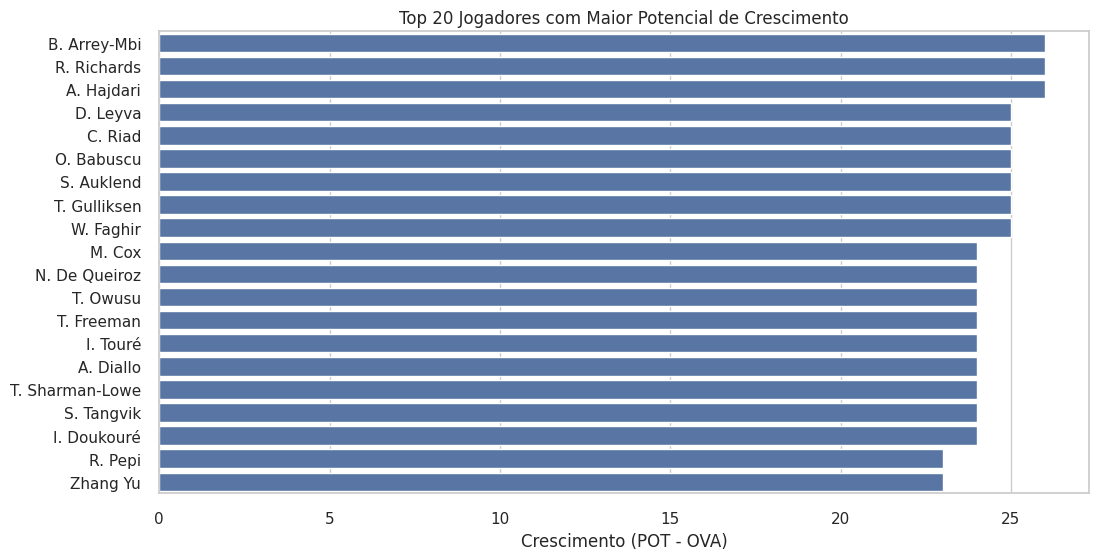

In [5]:
df['growth'] = df['potential_rating'] - df['overall_rating']
top_growth = df.sort_values('growth', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_growth,
    x='growth',
    y='name'
)

plt.title('Top 20 Jogadores com Maior Potencial de Crescimento')
plt.xlabel('Crescimento (POT - OVA)')
plt.ylabel('')
plt.show()


## Distribuição de Posições dos Jogadores
O gráfico mostra as 10 posições mais comuns entre os jogadores do FIFA 21.
As barras representam a quantidade de jogadores disponíveis em cada posição, permitindo identificar onde há maior oferta de atletas no jogo.

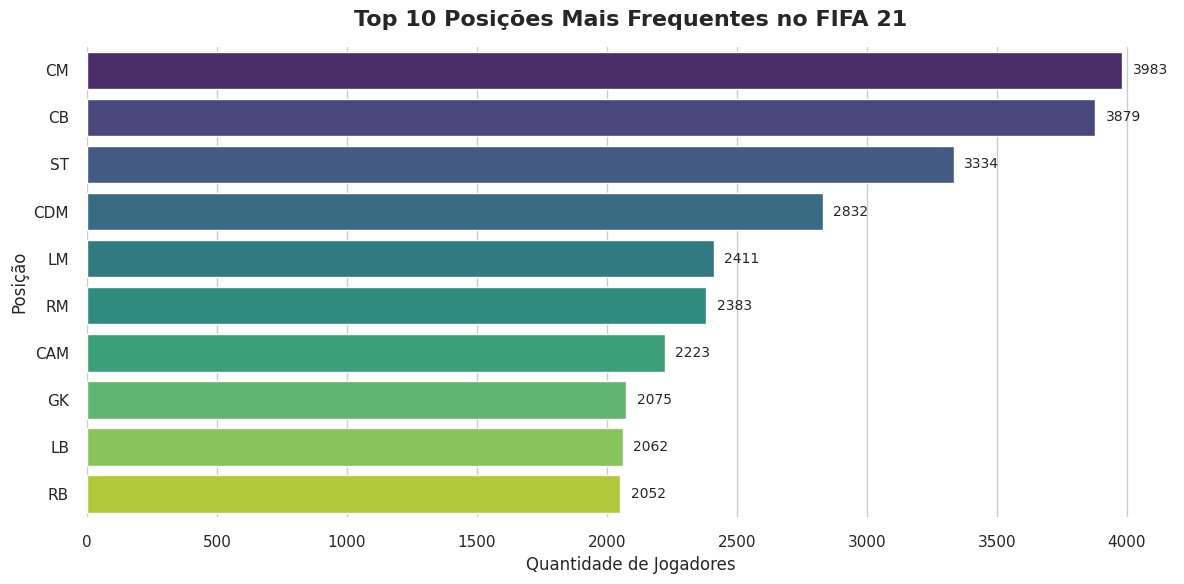

In [6]:
positions = (
    df["positions"]
    .dropna()
    .str.split(" ")
    .explode()
)

sns.set_theme(style="whitegrid", context="notebook")

top_positions = positions.value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = sns.barplot(
    x=top_positions.values,
    y=top_positions.index,
    hue=top_positions.index,  
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Posições Mais Frequentes no FIFA 21",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Quantidade de Jogadores", fontsize=12)
ax.set_ylabel("Posição", fontsize=12)

sns.despine(left=True, bottom=True)

for i, value in enumerate(top_positions.values):
    ax.text(
        value + (top_positions.values.max() * 0.01),
        i,
        f"{value}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Overall Médio por Time

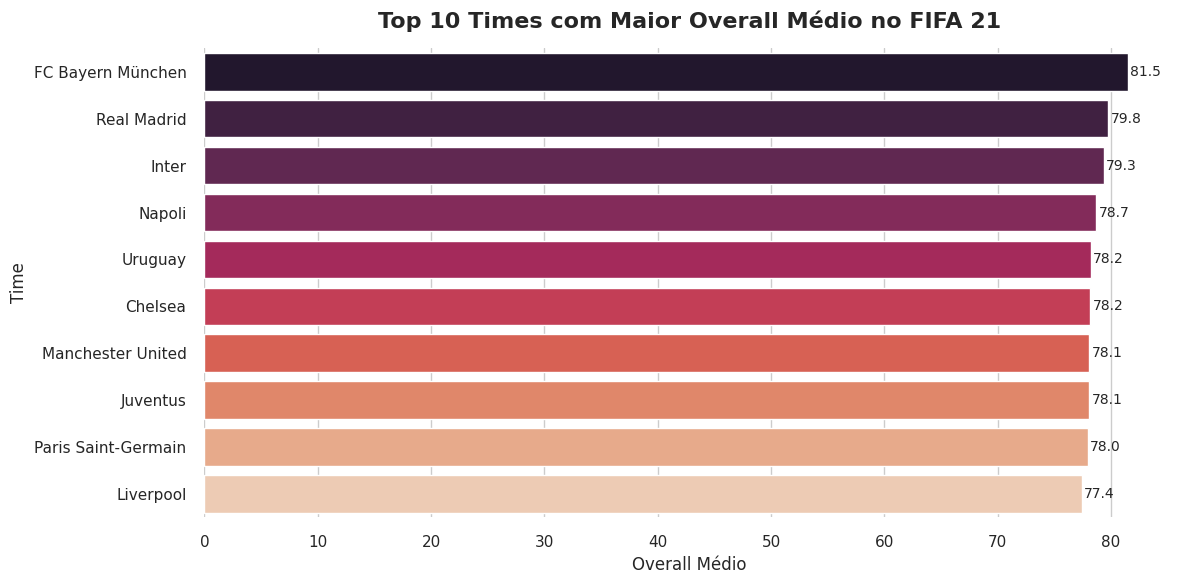

In [7]:
sns.set_theme(style="whitegrid", context="notebook")

team_overall = (
    df
    .dropna(subset=["team", "overall_rating"])
    .groupby("team", as_index=False)
    .agg(
        overall_medio=("overall_rating", "mean"),
        qtd_jogadores=("overall_rating", "count")
    )
)

team_overall = team_overall[team_overall["qtd_jogadores"] >= 10]

top_teams_overall = team_overall.sort_values(
    "overall_medio", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    x="overall_medio",
    y="team",
    hue="team",     
    data=top_teams_overall,
    palette="rocket",
    legend=False,      
    ax=ax
)

ax.set_title(
    "Top 10 Times com Maior Overall Médio no FIFA 21",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Overall Médio", fontsize=12)
ax.set_ylabel("Time", fontsize=12)

for i, value in enumerate(top_teams_overall["overall_medio"]):
    ax.text(
        value + 0.2,
        i,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Perfil Físico Médio dos Jogadores

In [8]:
df["height_cm"] = pd.to_numeric(df["height_cm"], errors="coerce")
df["weight_kg"] = pd.to_numeric(df["weight_kg"], errors="coerce")

avg_height = df["height_cm"].mean()
avg_weight = df["weight_kg"].mean()


In [9]:
physical_avg = pd.DataFrame({
    "Métrica": ["Altura Média (cm)", "Peso Médio (kg)"],
    "Valor": [avg_height, avg_weight]
})

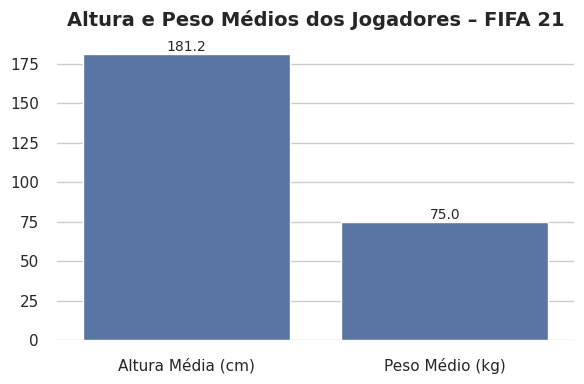

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=physical_avg,
    x="Métrica",
    y="Valor",
    ax=ax
)

ax.set_title(
    "Altura e Peso Médios dos Jogadores – FIFA 21",
    fontsize=14,
    weight="bold",
    pad=10
)

ax.set_ylabel("")
ax.set_xlabel("")

for i, value in enumerate(physical_avg["Valor"]):
    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Valor Médio de Mercado por Idade

In [11]:

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["value_eur"] = pd.to_numeric(df["value_eur"], errors="coerce")

df_age_value = df.dropna(subset=["age", "value_eur"])

In [12]:
df_age_value = (
    df
    .dropna(subset=["age", "value_eur"])
    .groupby("age", as_index=False)
    .agg(valor_medio=("value_eur", "mean"))
)

fig = px.line(
    df_age_value,
    x="age",
    y="valor_medio",
    markers=True,
    title="Valor Médio de Mercado por Idade – FIFA 21"
)

fig.update_yaxes(
    tickvals=[1e5, 5e5, 1e6, 5e6, 1e7, 5e7],
    ticktext=["€100k", "€500k", "€1M", "€5M", "€10M", "€50M"],
    title="Valor Médio (€)"
)

fig.update_layout(
    xaxis_title="Idade",
    template="plotly_white"
)

fig.show()

## Top 10 Times com Maior Tempo Médio de Contrato

In [13]:
df_contract = df.dropna(subset=["team", "contract_period"]).copy()

df_contract[["contract_start", "contract_end"]] = (
    df_contract["contract_period"]
    .str.split("~", expand=True)
)

df_contract["contract_start"] = pd.to_numeric(
    df_contract["contract_start"].str.strip(),
    errors="coerce"
)

df_contract["contract_end"] = pd.to_numeric(
    df_contract["contract_end"].str.strip(),
    errors="coerce"
)

df_contract["contract_duration"] = (
    df_contract["contract_end"] - df_contract["contract_start"]
)

df_contract = df_contract[df_contract["contract_duration"] > 0]


In [14]:
team_contract_avg = (
    df_contract
    .groupby("team", as_index=False)
    .agg(
        tempo_medio_contrato=("contract_duration", "mean"),
        qtd_jogadores=("contract_duration", "count")
    )
)

# Filtrar times com amostra mínima
team_contract_avg = team_contract_avg[
    team_contract_avg["qtd_jogadores"] >= 10
]

top_10_contracts = (
    team_contract_avg
    .sort_values("tempo_medio_contrato", ascending=False)
    .head(10)
)


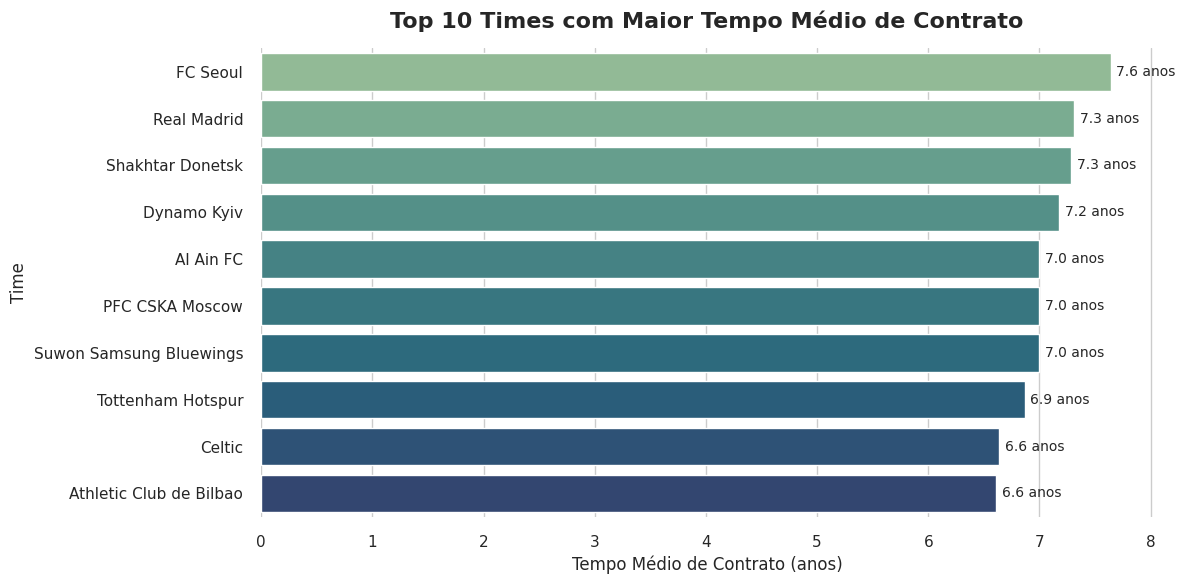

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_10_contracts,
    x="tempo_medio_contrato",
    y="team",
    hue="team",
    palette="crest",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Times com Maior Tempo Médio de Contrato",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Tempo Médio de Contrato (anos)", fontsize=12)
ax.set_ylabel("Time", fontsize=12)

for i, value in enumerate(top_10_contracts["tempo_medio_contrato"]):
    ax.text(
        value + 0.05,
        i,
        f"{value:.1f} anos",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Top 10 Times com Maiores Gastos com Salários

In [16]:
df_wages = (
    df
    .dropna(subset=["team", "wage_eur"])
    .groupby("team", as_index=False)
    .agg(
        gasto_total_salarios=("wage_eur", "sum"),
        qtd_jogadores=("wage_eur", "count")
    )
)

# Considerar apenas times com elenco mínimo
df_wages = df_wages[df_wages["qtd_jogadores"] >= 10]

top_10_wages = (
    df_wages
    .sort_values("gasto_total_salarios", ascending=False)
    .head(10)
)


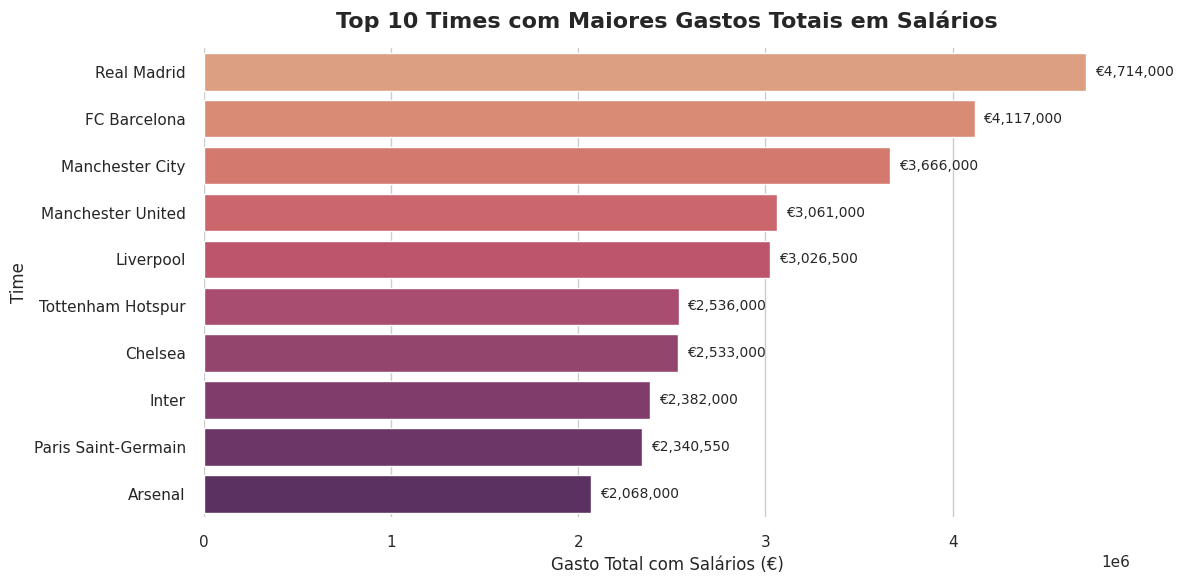

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_10_wages,
    x="gasto_total_salarios",
    y="team",
    hue="team",
    palette="flare",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Times com Maiores Gastos Totais em Salários",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Gasto Total com Salários (€)", fontsize=12)
ax.set_ylabel("Time", fontsize=12)

for i, value in enumerate(top_10_wages["gasto_total_salarios"]):
    ax.text(
        value + (top_10_wages["gasto_total_salarios"].max() * 0.01),
        i,
        f"€{value:,.0f}",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## Top 10 Jogadores com Maior Dribbling

In [18]:
df_dribbling = (
    df
    .dropna(subset=["name", "dribbling"])
    .sort_values("dribbling", ascending=False)
    .head(10)
)


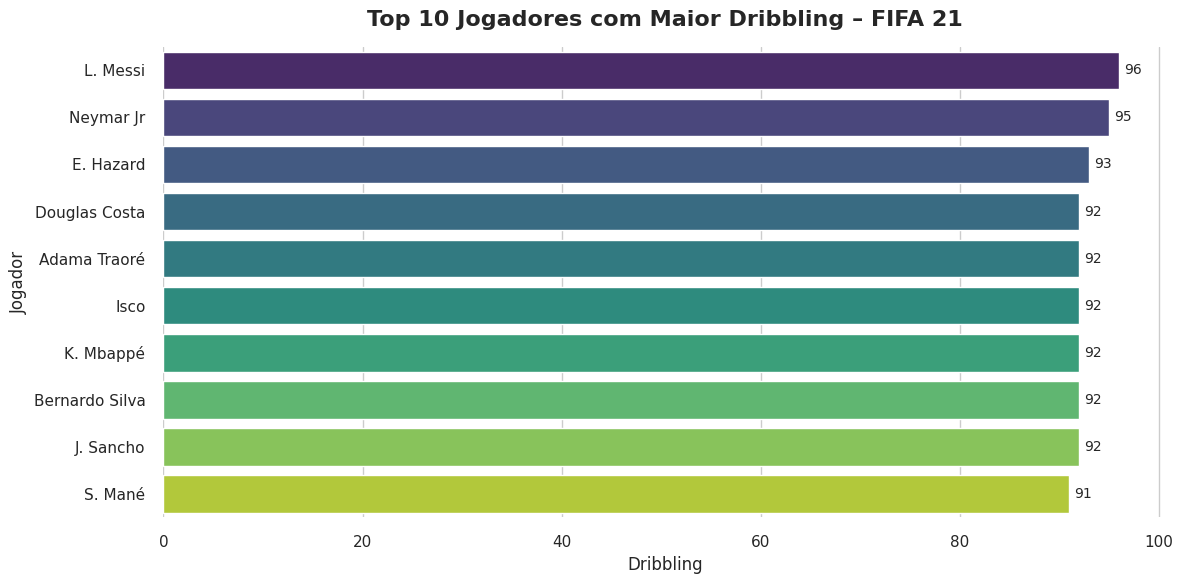

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_dribbling,
    x="dribbling",
    y="name",
    hue="name",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Jogadores com Maior Dribbling – FIFA 21",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Dribbling", fontsize=12)
ax.set_ylabel("Jogador", fontsize=12)

for i, value in enumerate(df_dribbling["dribbling"]):
    ax.text(
        value + 0.5,
        i,
        f"{int(value)}",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
def map_position(pos):
    if "GK" in pos:
        return "Goleiro"
    elif any(p in pos for p in ["CB", "RB", "LB", "RWB", "LWB"]):
        return "Defesa"
    elif any(p in pos for p in ["CM", "CDM", "CAM"]):
        return "Meio-campo"
    else:
        return "Ataque"

df["position_group"] = df["positions"].apply(map_position)


In [20]:
fig = px.box(
    df,
    x="position_group",
    y="value_eur",
    points="all",
    log_y=True,
    title="Distribuição do Valor de Mercado por Macro-Posição",
    hover_data={
        "name": True,
        "overall_rating": True,
        "age": True,
        "team": True
    },
    labels={
        "position_group": "Posição",
        "value_eur": "Valor de Mercado (€)"
    }
)

fig.update_traces(jitter=0.3)
fig.update_layout(template="plotly_white")

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['player_id', 'long_name', 'name', 'nationality', 'positions', 'age', 'overall_rating', 'potential_rating', 'team', 'contract_period', 'height_cm', 'weight_kg', 'preferred_foot', 'best_overall_rating', 'best_position', 'growth', 'joined_date', 'value_eur', 'wage_eur', 'release_clause_eur', 'attacking_total', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'skill_total', 'dribbling', 'curve', 'fk_accuracy', 'long_passing', 'ball_control', 'movement_total', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'power_total', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'mentality_total', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'defending_total', 'marking', 'standing_tackle', 'sliding_tackle', 'goalkeeping_total', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes', 'total_stats', 'base_